# **Trabajo Práctico N°1: modelo predictivo de tarifas de Uber**


# Contexto del problema

El proyecto se centra en el análisis de datos de viajes realizados por Uber. El objetivo principal es predecir la tarifa de futuros viajes (`fare_amount`) a partir de distintas características disponibles en el dataset. El dataset utilizado contiene información sobre viajes realizados en Uber junto con el costo de cada uno. Cada fila representa un viaje individual e incluye distintas variables descriptivas que permiten caracterizarlo.

Variables de entrada:

- **key**: identificador único del viaje.
- **pickup_datetime**: fecha y hora en que comienza el viaje.
- **passenger_count**: cantidad de pasajeros en el vehículo.
- **pickup_longitude / pickup_latitude**: coordenadas geográficas donde inicia el viaje.
- **dropoff_longitude / dropoff_latitude**: coordenadas geográficas donde finaliza el viaje.

Variable objetivo

- **fare_amount**: costo total del viaje en dólares (USD), variable que se desea predecir.


# Importación de librerias


In [2]:
import pandas as pd
import numpy as np
import holidays
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Importación de datos


In [3]:
df = pd.read_csv("uber_fares.csv")

# Análisis descriptivo

En primer lugar, se cuenta con un total de 200.000 registros, lo que representa un volumen de datos adecuado para el entrenamiento de modelos.

Sin embargo, se detectan inconsistencias importantes en algunas variables. En particular, las coordenadas geográficas presentan valores fuera de rango (por ejemplo, longitudes y latitudes extremadamente grandes), lo cual indica la presencia de datos erróneos. A su vez, la variable `passenger_count` contiene valores atípicos, como 0 pasajeros o valores altos, que no tienen sentido en el contexto del problema. Por otro lado, se observa la presencia de una cantidad mínima de valores faltantes, por lo que se optará por eliminarlos sin afectar significativamente el dataset. Finalmente, la variable objetivo `fare_amount` presenta una distribución sesgada hacia valores altos.


In [4]:
print(df.columns)
df.info()
df.describe()

Index(['key', 'date', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.362915,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.943248,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,1.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,5.970000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.430000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.660000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,503.130000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [5]:
df.isnull().sum()

key                  0
date                 0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [6]:
df[df.isnull().any(axis=1)]

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
87946,32736015,2013-07-02 03:53:05,24.15,2013-07-02 03:53:05 UTC,-73.950581,40.779692,NaN,NaN,0


# Limpieza de datos


ANALISIS DE LOS DATOS ATIPICOS Y DATOS FALTANTES


Análisis de las variables geograficas


In [7]:
#borramos la fila que no tiene latitud ni longitud de destino
df = df.dropna(subset='dropoff_latitude')

condicion = ((df['pickup_latitude'] > 90) | (df['pickup_latitude'] < -90) |
    (df['pickup_longitude'] > 180) | (df['pickup_longitude'] < -180) |
    (df['dropoff_latitude'] > 90) | (df['dropoff_latitude'] < -90) |
    (df['dropoff_longitude'] > 180) | (df['dropoff_longitude'] < -180))

#las columnas que nos interesan
df.loc[condicion, ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']]

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
4949,40.739957,-748.016667,40.734192,-74.003570
32549,40.715155,-74.016055,40.697862,-737.916665
48506,40.770092,-735.200000,40.765530,-73.980187
56617,404.433332,-73.960828,40.769037,-73.988357
61793,401.066667,-73.951385,40.754117,-73.982110
75851,1644.421482,-1340.648410,872.697628,-3356.666300
91422,1292.016128,57.418457,-881.985513,1153.572603
103745,40.767035,-736.216667,40.725562,-73.982377
139447,40.709780,-74.011042,493.533332,-73.983163
144253,40.757812,-768.550000,40.740007,-73.997040


In [8]:
#eliminamos las filas que seguian siendo inconsistentes a pesar de la condicion
df = df.drop(df[(df['pickup_latitude'] > 1000)].index)

pickup_lat = (df['pickup_latitude'] > 90) | (df['pickup_latitude'] < -90)
pickup_lon = (df['pickup_longitude'] > 180) | (df['pickup_longitude'] < -180)
drop_lat   = (df['dropoff_latitude'] > 90) | (df['dropoff_latitude'] < -90)
drop_lon   = (df['dropoff_longitude'] > 180) | (df['dropoff_longitude'] < -180)

df.loc[pickup_lat, 'pickup_latitude'] /= 10
df.loc[pickup_lon, 'pickup_longitude'] /= 10
df.loc[drop_lat, 'dropoff_latitude']  /= 10
df.loc[drop_lon, 'dropoff_longitude'] /= 10

condicion = ((df['pickup_latitude'] > 90) | (df['pickup_latitude'] < -90) |
    (df['pickup_longitude'] > 180) | (df['pickup_longitude'] < -180) |
    (df['dropoff_latitude'] > 90) | (df['dropoff_latitude'] < -90) |
    (df['dropoff_longitude'] > 180) | (df['dropoff_longitude'] < -180))

df.loc[condicion, ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']]

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude


In [9]:
df.isnull().sum() #chequeo

key                  0
date                 0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

Tratamiento de valores atípicos en coordenadas geográficas: se analizaron las variables de latitud y longitud correspondientes a los puntos de inicio y fin de los viajes. Se detectaron valores fuera de los rangos válidos (latitud entre -90 y 90, longitud entre -180 y 180), los cuales no representan ubicaciones reales y se deben a errores en los datos. Dado que no es posible corregir estos valores de manera confiable, se decidió eliminar los registros que contienen coordenadas inválidas.


Análisis de la variable `passenger_count`: cantidad de pasajeros


In [10]:
df['passenger_count'].describe() #podemos observar valores incoherentes, como la maxima y la minima

count    199997.00000
mean          1.68455
std           1.38600
min           0.00000
25%           1.00000
50%           1.00000
75%           2.00000
max         208.00000
Name: passenger_count, dtype: float64

In [11]:
#eliminamos los menores a 1 y los mayores que 6
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] < 7)] 

In [12]:
df['passenger_count'].describe()  #chequeo

count    199288.000000
mean          1.689500
std           1.305424
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           6.000000
Name: passenger_count, dtype: float64

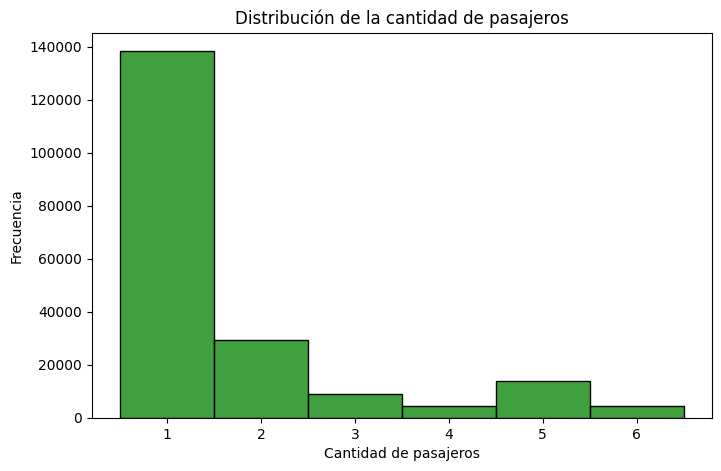

In [13]:
plt.figure(figsize=(8,5)) 
sns.histplot(df['passenger_count'], bins=10, discrete=True, color="green")
plt.title("Distribución de la cantidad de pasajeros")
plt.xlabel("Cantidad de pasajeros")
plt.ylabel("Frecuencia")
plt.show()

Tratamiento de valores atípicos en `passenger_count`: se detectaron valores atípicos como 0 pasajeros y valores excesivamente altos, los cuales no son coherentes con la capacidad de un vehículo típico. Por este motivo, se decidió conservar únicamente los valores entre 1 y 6 pasajeros, eliminando aquellos registros que no representan situaciones reales.


Análisis de la variable `fare_amount`: costo de viaje


In [14]:
df['fare_amount'].describe()

count    199288.000000
mean         11.369517
std           9.952179
min           1.000000
25%           5.970000
50%           8.430000
75%          12.670000
max         503.130000
Name: fare_amount, dtype: float64

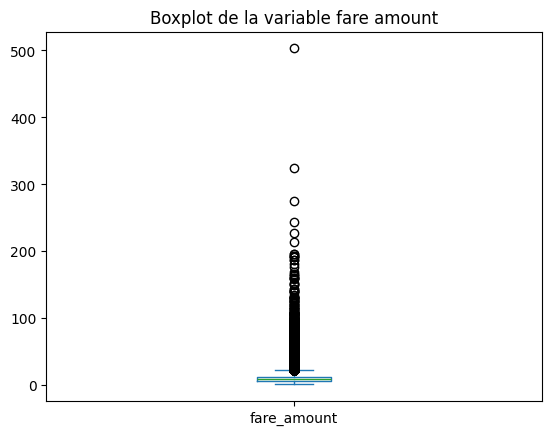

In [15]:
df['fare_amount'].head()

df['fare_amount'].plot(kind='box')
plt.title("Boxplot de la variable fare amount")
plt.show()


Podemos observar que hay mucha cantidad de outliers y que la mayoria de los viajes tienen costos bajos ya que la caja esta cerca del cero. Por lo cual decidimos quedarnos con el 99% de los datos para descartar estos valores ya que eran extremos y lo consideramos anomailias (errores del sistema o viajes muy largos)


In [16]:
df = df[df['fare_amount'] > 0]
fare_amount2= df['fare_amount'].quantile(0.99) #nos quedamos con el 99% de los datos eliminando outliers
df = df[df['fare_amount'] <= fare_amount2]

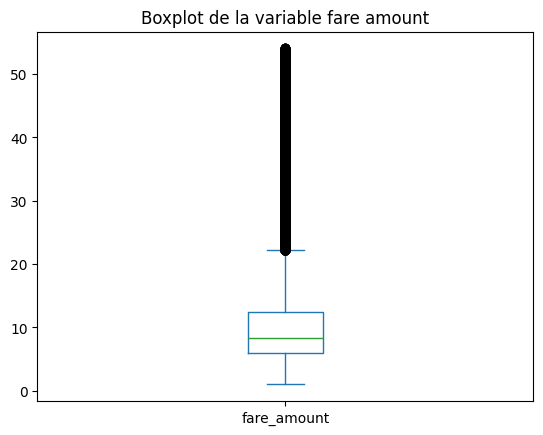

In [17]:
df['fare_amount'].plot(kind='box') 
plt.title("Boxplot de la variable fare amount") 
plt.show()

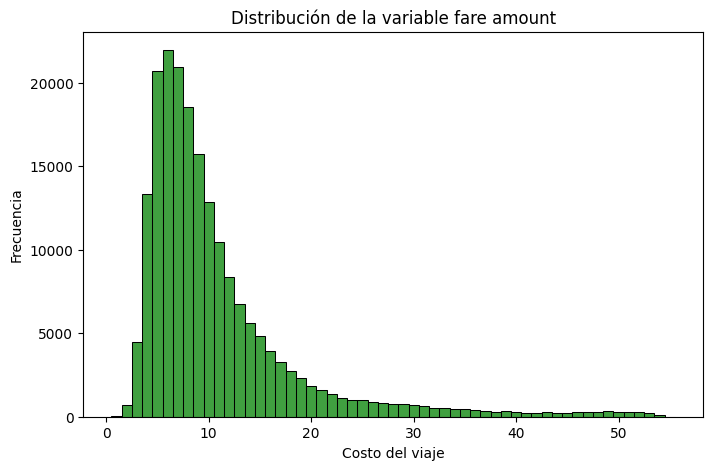

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['fare_amount'], bins=10, discrete=True, color="green")
plt.title("Distribución de la variable fare amount")
plt.xlabel("Costo del viaje")
plt.ylabel("Frecuencia")
plt.show()

Con los datos limpios, y gracias a la visualizacion del histograma, podemos observar que la mayoria de los viajes cuestan entre 5 y 10 dolares, y la frecuencia decae a medida que aumenta el costo del viaje


Agregamos la variable distancia en KM


In [19]:
def haversine(lat1, lon1, lat2, lon2): #fórmula utilizada para calcular la distancia entre dos puntos de una esfera dadas sus coordenadas de longitud y latitu
    #radio de la Tierra en km
    R = 6371
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2]) #convertimos grados a radianes
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

df['distance_km'] = haversine(
    df['pickup_latitude'],  df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude'])

In [20]:
df["distance_km"].describe() #podemos observar que el valor maximo es extremo

count    197296.000000
mean         19.652855
std         370.634255
min           0.000000
25%           1.210509
50%           2.104390
75%           3.804673
max        8782.898606
Name: distance_km, dtype: float64

Convertimos el tipo de dato y creamos variables nuevas: hour, day_of_week, year y month.


In [21]:
pickup_dt = pd.to_datetime(df['pickup_datetime'])

df['hour']        = pickup_dt.dt.hour         #0-23
df['day_of_week'] = pickup_dt.dt.dayofweek    #0=lunes, 6=domingo
df['month']       = pickup_dt.dt.month        
df['year']        = pickup_dt.dt.year

Trasformación de variables


In [22]:
us_holidays = holidays.US(years=df['year'].unique(), state='NY') #feriados de NY

#es día laborable si no es fin de semana ni feriado
df['date'] = pd.to_datetime(df['date'])
df['is_workday'] = df['date'].apply(lambda x: 0 if (x.weekday() >= 5 or x.date() in us_holidays) else 1)

def get_day_period(hour):
    if 6 <= hour < 12:
        return 1  #mañana
    elif 12 <= hour < 17:
        return 2  #tarde
    elif 17 <= hour < 21:
        return 3  #nochecita
    else:
        return 0  #noche
df['day_period'] = df['hour'].apply(get_day_period)

In [23]:
#probamos variables
print(df[['is_workday', 'day_period']].value_counts())
print(df[['is_workday', 'day_period']].isnull().sum())

is_workday  day_period
1           1             37288
            0             34391
            3             32655
            2             31779
0           0             22884
            2             15026
            3             13040
            1             10233
Name: count, dtype: int64
is_workday    0
day_period    0
dtype: int64


Limpiamos la variable Distancia


In [24]:
#los viajes con distancia 0 son probablemente errores
df = df[df['distance_km'] > 0]

#se eliminarin outliers de distancia muy largas
dist_max = df['distance_km'].quantile(0.99) 
df = df[df['distance_km'] <= dist_max]

In [25]:
df["distance_km"].describe()

count    189868.000000
mean          3.067942
std           2.828766
min           0.000084
25%           1.267314
50%           2.144491
75%           3.801968
max          19.890741
Name: distance_km, dtype: float64

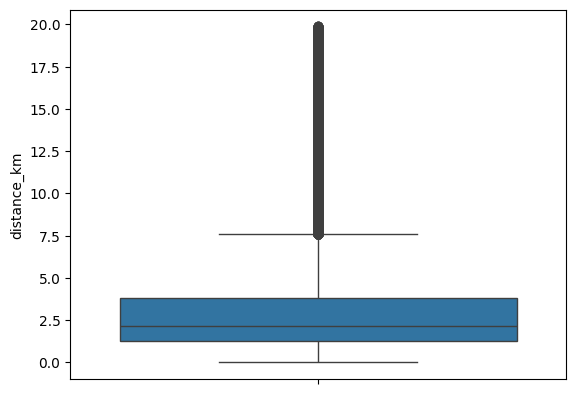

In [26]:
sns.boxplot(df["distance_km"])
plt.show()

El 50% de los datos son cortos, concentrado entre 1 y 4km. Tambien observamos que tenemos muchos viajes, que aunque son reales, se alejan de la media


Cantidad de viajes por hora , mes y año


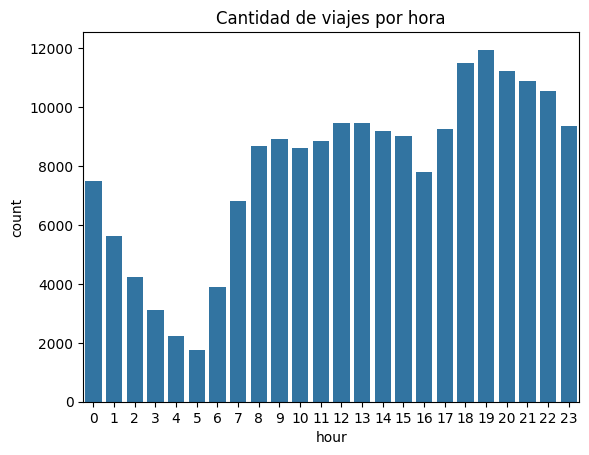

In [27]:
sns.countplot(x=df["hour"])
plt.title("Cantidad de viajes por hora")
plt.show()

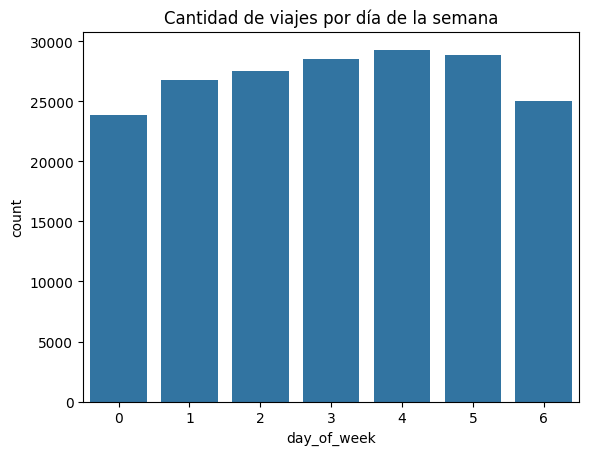

In [51]:
sns.countplot(x=df["day_of_week"])
plt.title("Cantidad de viajes por día de la semana")
plt.show()

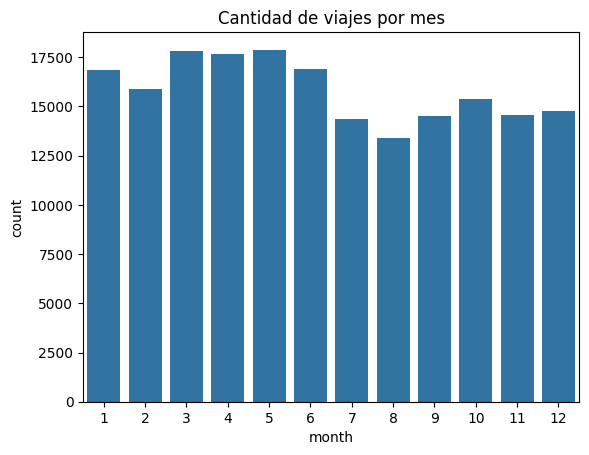

In [52]:
sns.countplot(x=df["month"])
plt.title("Cantidad de viajes por mes")
plt.show()

Se realizaron gráficos de frecuencia para analizar la cantidad de viajes según variables temporales como hora, día de la semana y mes. Se observaron patrones de demanda, con mayores concentraciones en determinados horarios y días, lo cual resulta relevante para la comprensión del comportamiento del sistema.


In [28]:
df.columns

Index(['key', 'date', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count', 'distance_km', 'hour', 'day_of_week', 'month',
       'year', 'is_workday', 'day_period'],
      dtype='object')

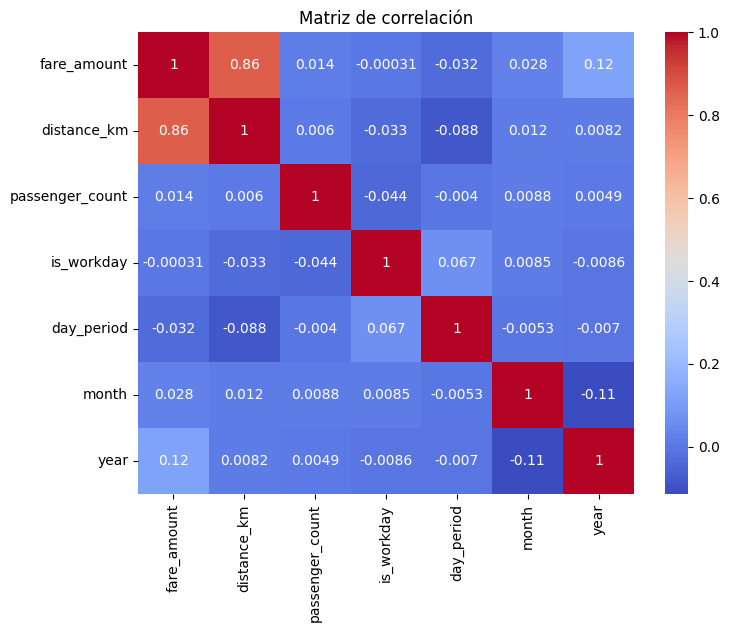

In [29]:
cols = ['fare_amount', 'distance_km', 'passenger_count', "is_workday","day_period", 'month', "year"]
corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

In [41]:
print(df.columns.tolist())


['key', 'date', 'fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'distance_km', 'hour', 'day_of_week', 'month', 'year', 'is_workday', 'day_period_1', 'day_period_2', 'day_period_3']


In [53]:
df["day_of_week"].unique()

array([3, 4, 0, 6, 1, 5, 2], dtype=int32)

In [36]:
df = pd.get_dummies(df, columns=["day_period"], drop_first=True)

In [43]:
#HAGO ESCALADO PARA PODER HACER LUEGO LA VALIDACION, ( CUALQUIER COSA LO BORRAMOS)



# 2) Definir X e y
X = df[[
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "passenger_count",
    "distance_km",
    "hour",
    "day_of_week",
    "month",
    "year",
    "is_workday",
    "day_period_1",
    "day_period_2",
    "day_period_3"
]]

y = df["fare_amount"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Se dividió el conjunto de datos en entrenamiento (80%) y prueba (20%) utilizando train_test_split. Esta separación permite evaluar el modelo sobre datos no vistos, evitando sobreajuste y garantizando una estimación más realista del rendimiento.


In [ ]:
#CAPAZ LO USEMOS PARA EL PUNTO 4 DE LA PARTE 4

""" 
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X_train_scaled, y_train)
y_pred = modelo.predict(X_test_scaled)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)  """

LinearRegression


In [44]:

modelo_lr = LinearRegression()

modelo_lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [45]:
y_pred_train = modelo_lr.predict(X_train_scaled)
y_pred_test = modelo_lr.predict(X_test_scaled)

In [46]:

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import numpy as np
import pandas as pd
# Métricas para train
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

# Métricas para test
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

In [47]:
metricas = {
    "MSE": {"Train": mse_train, "Test": mse_test},
    "RMSE": {"Train": rmse_train, "Test": rmse_test},
    "MAE": {"Train": mae_train, "Test": mae_test},
    "MAPE": {"Train": mape_train, "Test": mape_test},
    "R2": {"Train": r2_train, "Test": r2_test}
}

df_metricas = pd.DataFrame(metricas).T
print(df_metricas)

          Train       Test
MSE   12.711167  13.075204
RMSE   3.565272   3.615965
MAE    2.115901   2.130717
MAPE   0.220799   0.218456
R2     0.766668   0.760349


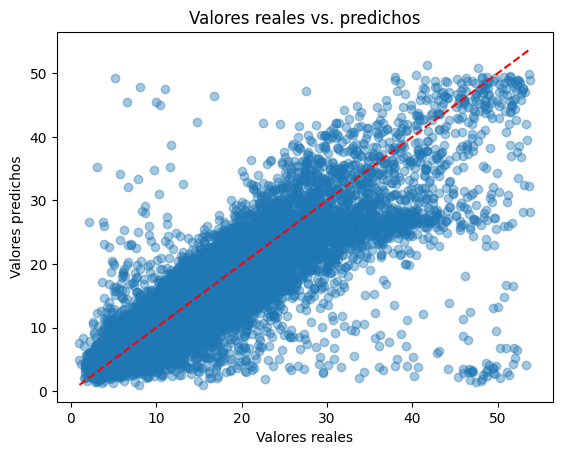

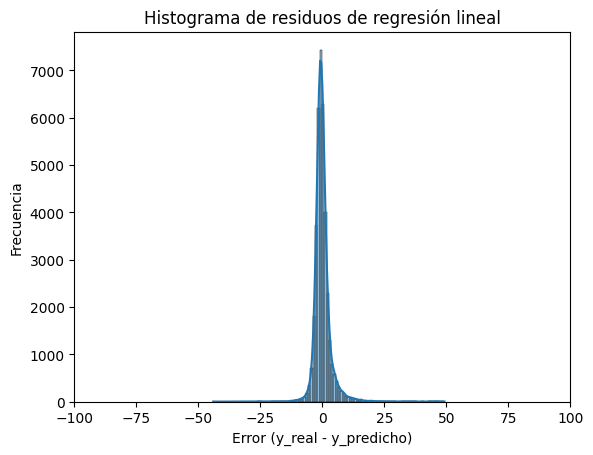

In [48]:
# Gráfico: valores reales vs predichos
plt.scatter(y_test, y_pred_test, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Valores reales vs. predichos")
plt.show()

# Residuos
residuos_reg = y_test - y_pred_test

sns.histplot(residuos_reg, bins=100, alpha=0.5, kde=True)
plt.title("Histograma de residuos de regresión lineal")
plt.xlabel("Error (y_real - y_predicho)")
plt.ylabel("Frecuencia")
plt.xlim(-100, 100)
plt.show()

El gráfico muestra que el modelo logra capturar la relación general entre las variables, observándose una tendencia creciente entre valores reales y predichos. Sin embargo, se aprecia una dispersión considerable, especialmente para valores altos, lo que indica que el modelo presenta errores de predicción en esos casos.


El modelo de regresión lineal múltiple logra capturar la relación general entre las variables explicativas y la variable objetivo. No obstante, se observa dispersión en las predicciones, particularmente en valores elevados, lo que indica limitaciones en la capacidad del modelo para ajustarse completamente a los datos. El análisis de residuos muestra que los errores se concentran en torno a cero, aunque existen valores extremos, sugiriendo que el modelo podría mejorarse incorporando nuevas variables o técnicas más complejas.
